# Radio ML Model

In [1]:
#
# Copyright (C) 2024, Advanced Micro Devices, Inc. All rights reserved.
# SPDX-License-Identifier: MIT
#
# Author: Faisal El Shabani

### Import Libraries

In [2]:
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPooling1D
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision
from sklearn.model_selection import train_test_split
import h5py as h5
import numpy as np
from numpy import argwhere
import os
import json
import statistics
import shutil

2025-08-14 14:52:47.469835: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-14 14:52:47.474612: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-14 14:52:47.484371: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755204767.499277 3196037 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755204767.503564 3196037 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755204767.518799 3196037 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

### Read training and test data

In [3]:
if not("RADIOML_DATA" in os.environ):
    print("Please set environment variable RADIOML_DATA to point to dataset found in https://www.kaggle.com/datasets/pinxau1000/radioml2018")
data_file = os.environ["RADIOML_DATA"] + 'GOLD_XYZ_OSC.0001_1024.hdf5'
file_handle = h5.File(data_file,'r')

myData = file_handle['X'][:]  #1024x2 samples 
myMods = file_handle['Y'][:]  #mods 
mySNRs = file_handle['Z'][:]  #snrs  

modulation_classes = json.load(open(os.environ["RADIOML_DATA"] + "classes-fixed.json", 'r'))

print(np.shape(myData))
print(np.shape(myMods))
print(np.shape(mySNRs))
file_handle.close()

(2555904, 1024, 2)
(2555904, 24)
(2555904, 1)


### Examine RF input samples, 30 dB SNR case

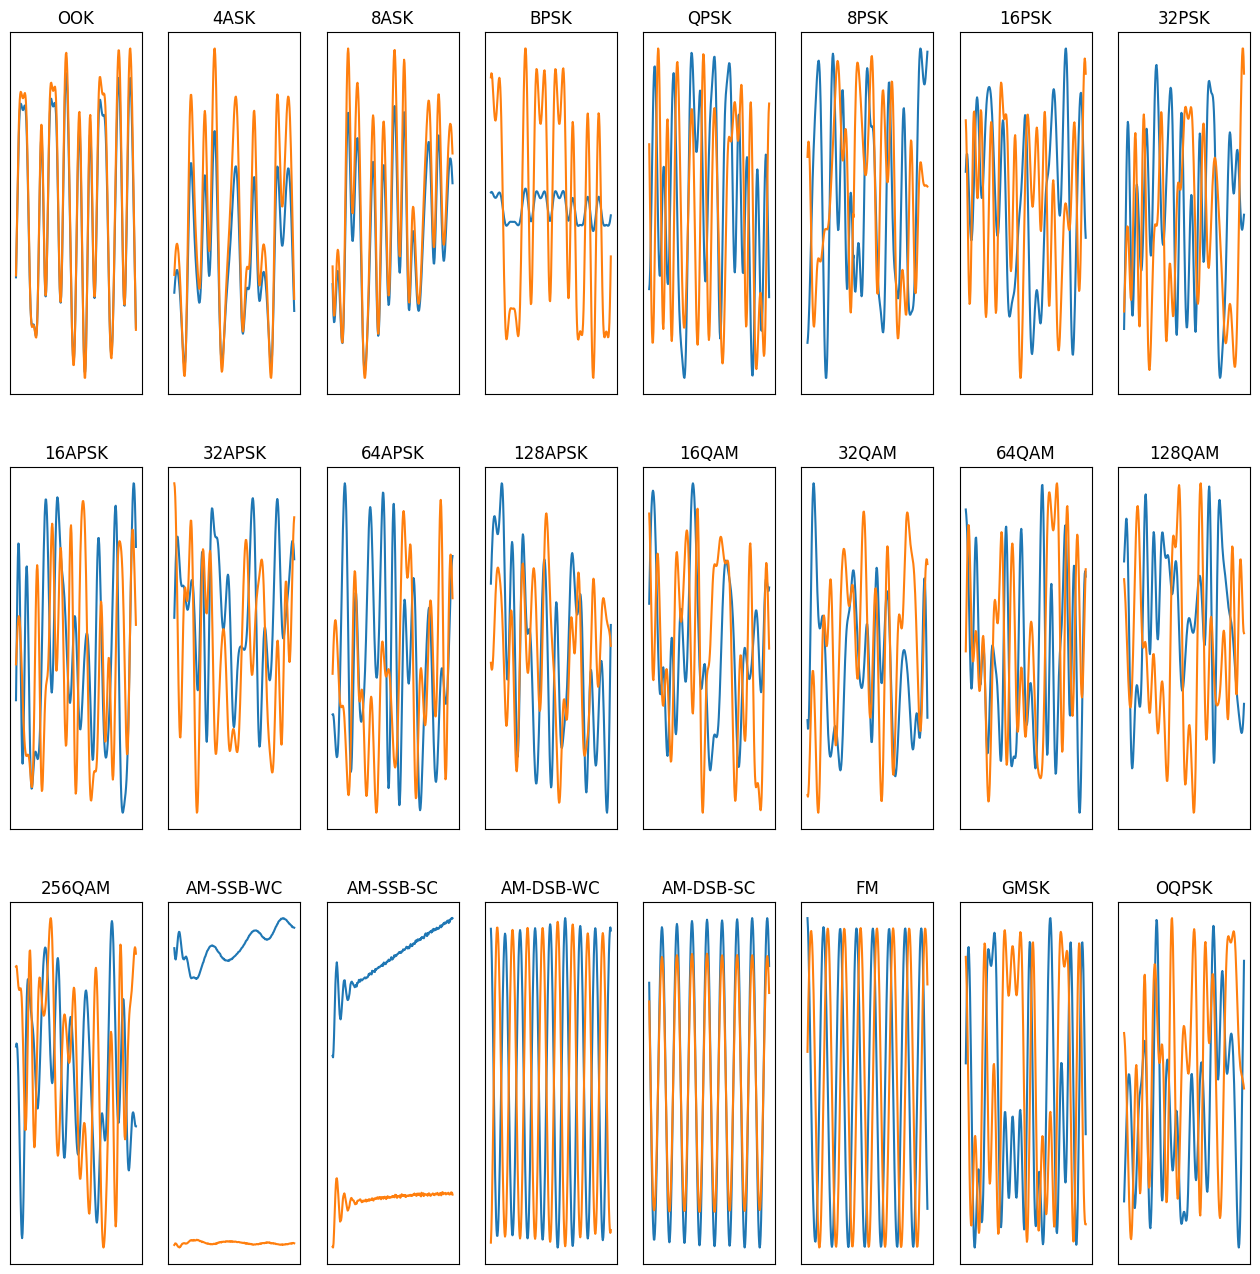

In [14]:
myDataReshaped = myData.reshape(24,26,4096,1024,2) #(modulation,SNR,frame,I,Q)
plt.rcParams['figure.figsize'] = [16, 16]
plt.rcParams['figure.dpi'] = 100
for x in range(len(myDataReshaped)):
  plt.subplot(3, 8, x+1)
  plt.title(modulation_classes[x], fontsize=12, fontweight='bold')
  plt.plot(myDataReshaped[x,25,0,:256,0], linewidth=1.5)
  plt.plot(myDataReshaped[x,25,0,:256,1], linewidth=1.5)
  plt.xticks([])
  plt.yticks([])
plt.tight_layout()
plt.savefig('images/modulation_timedomain.png', dpi=300, bbox_inches='tight')

### Split training and test data

In [5]:
X_train ,X_test ,Y_train ,Y_test, Z_train, Z_test =train_test_split(myData, myMods, mySNRs, test_size=0.2, random_state=0)
print (np.shape(X_test))
print (np.shape(Y_test))
print (np.shape(Z_test))
print (np.shape(X_train))
print (np.shape(Y_train))
print (np.shape(Z_train))

(511181, 1024, 2)
(511181, 24)
(511181, 1)
(2044723, 1024, 2)
(2044723, 24)
(2044723, 1)


### Build CNN Model

In [6]:
inputs = keras.Input(shape=(1024,2),name="input")
x1 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w1",activation='relu')(inputs)
x2 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w2")(x1)
x3 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w3",activation='relu')(x2)
x4 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w4")(x3)
x5 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w5",activation='relu')(x4)
x6 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w6")(x5)
x7 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w7",activation='relu')(x6)
x8 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w8")(x7)
x9 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w9",activation='relu')(x8)
x10 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w10")(x9)
x11 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w11",activation='relu')(x10)
x12 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w12")(x11)
x13 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w13",activation='relu')(x12)
x14 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="MaxPool1D_w14")(x13)
x15 = Flatten(name="flatten_w15")(x14)
x16 = Dense(128, activation="selu",name="dense_w16")(x15)
x18 = Dense(128, activation="selu",name="dense_w17")(x16)
outputs = Dense(24,activation="softmax",name="dense_w18")(x18)
model = keras.Model(inputs=inputs,outputs=outputs)
optimizer = keras.optimizers.RMSprop(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.summary()


2025-08-14 14:53:54.633186: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1024, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w1 (Conv1D)              │ (None, 1024, 64)       │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w2 (MaxPooling1D)    │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w3 (Conv1D)              │ (None, 512, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w4 (MaxPooling1D)    │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w5 (Conv1D)              │ (None, 256, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w6 (MaxPooling1D)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w7 (Conv1D)              │ (None, 128, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w8 (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w9 (Conv1D)              │ (None, 64, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w10 (MaxPooling1D)   │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w11 (Conv1D)             │ (None, 32, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w12 (MaxPooling1D)   │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w13 (Conv1D)             │ (None, 16, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1D_w14 (MaxPooling1D)    │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_w15 (Flatten)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_w16 (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_w17 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_w18 (Dense)               │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,648 (1010.34 KB)

 Trainable params: 258,648 (1010.34 KB)

 Non-trainable params: 0 (0.00 B)

### Training Model

Epoch 1/100
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 1280s 640ms/step - accuracy: 0.2170 - loss: 2.3478 - val_accuracy: 0.3456 - val_loss: 1.7990
Epoch 2/100
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 1260s 631ms/step - accuracy: 0.3627 - loss: 1.7594 - val_accuracy: 0.4005 - val_loss: 1.6480
Epoch 3/100
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 1264s 633ms/step - accuracy: 0.3937 - loss: 1.6701 - val_accuracy: 0.4252 - val_loss: 1.6038
Epoch 4/100
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 1260s 631ms/step - accuracy: 0.4294 - loss: 1.5949 - val_accuracy: 0.4523 - val_loss: 1.5864
Epoch 5/100
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 1255s 629ms/step - accuracy: 0.4808 - loss: 1.4845 - val_accuracy: 0.5163 - val_loss: 1.3972
Epoch 6/100
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 1280s 641ms/step - accuracy: 0.5110 - loss: 1.4106 - val_accuracy: 0.5323 - val_loss: 1.3527
Epoch 7/100
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 1282s 642ms/step - accuracy: 0.5330 - loss: 1.3556 - val_accuracy: 0.5258 - val_loss: 1.3911
Epoch 8/100
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 1271s

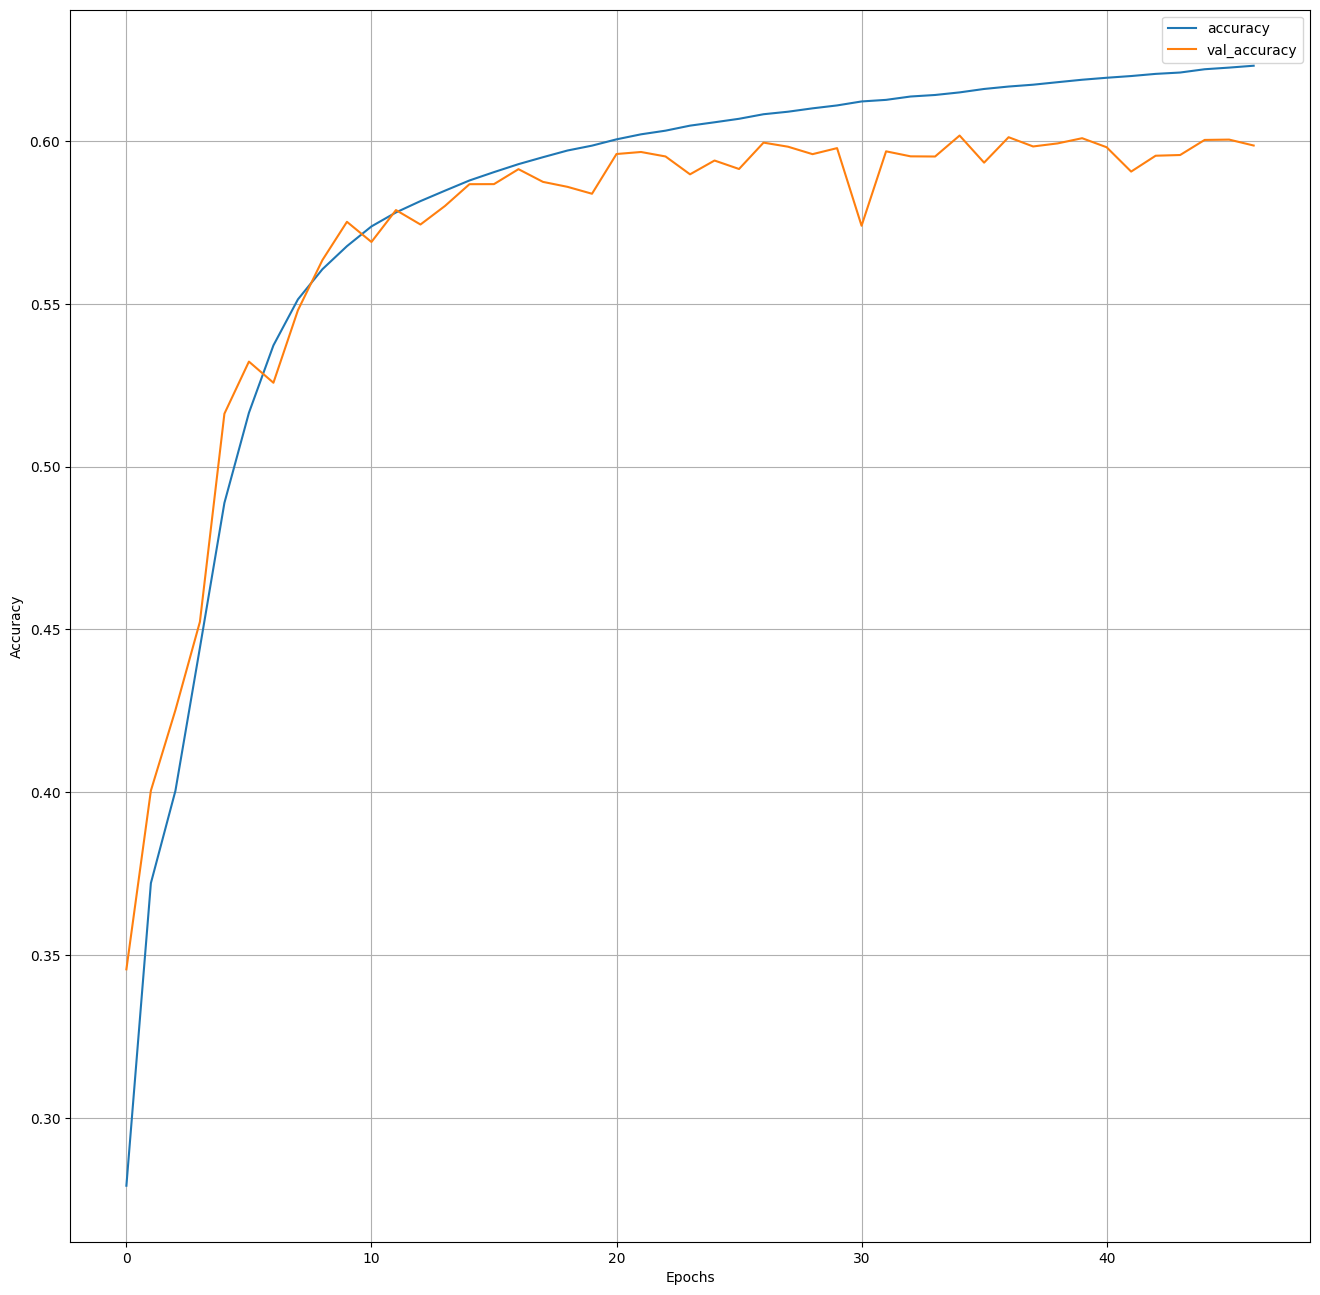

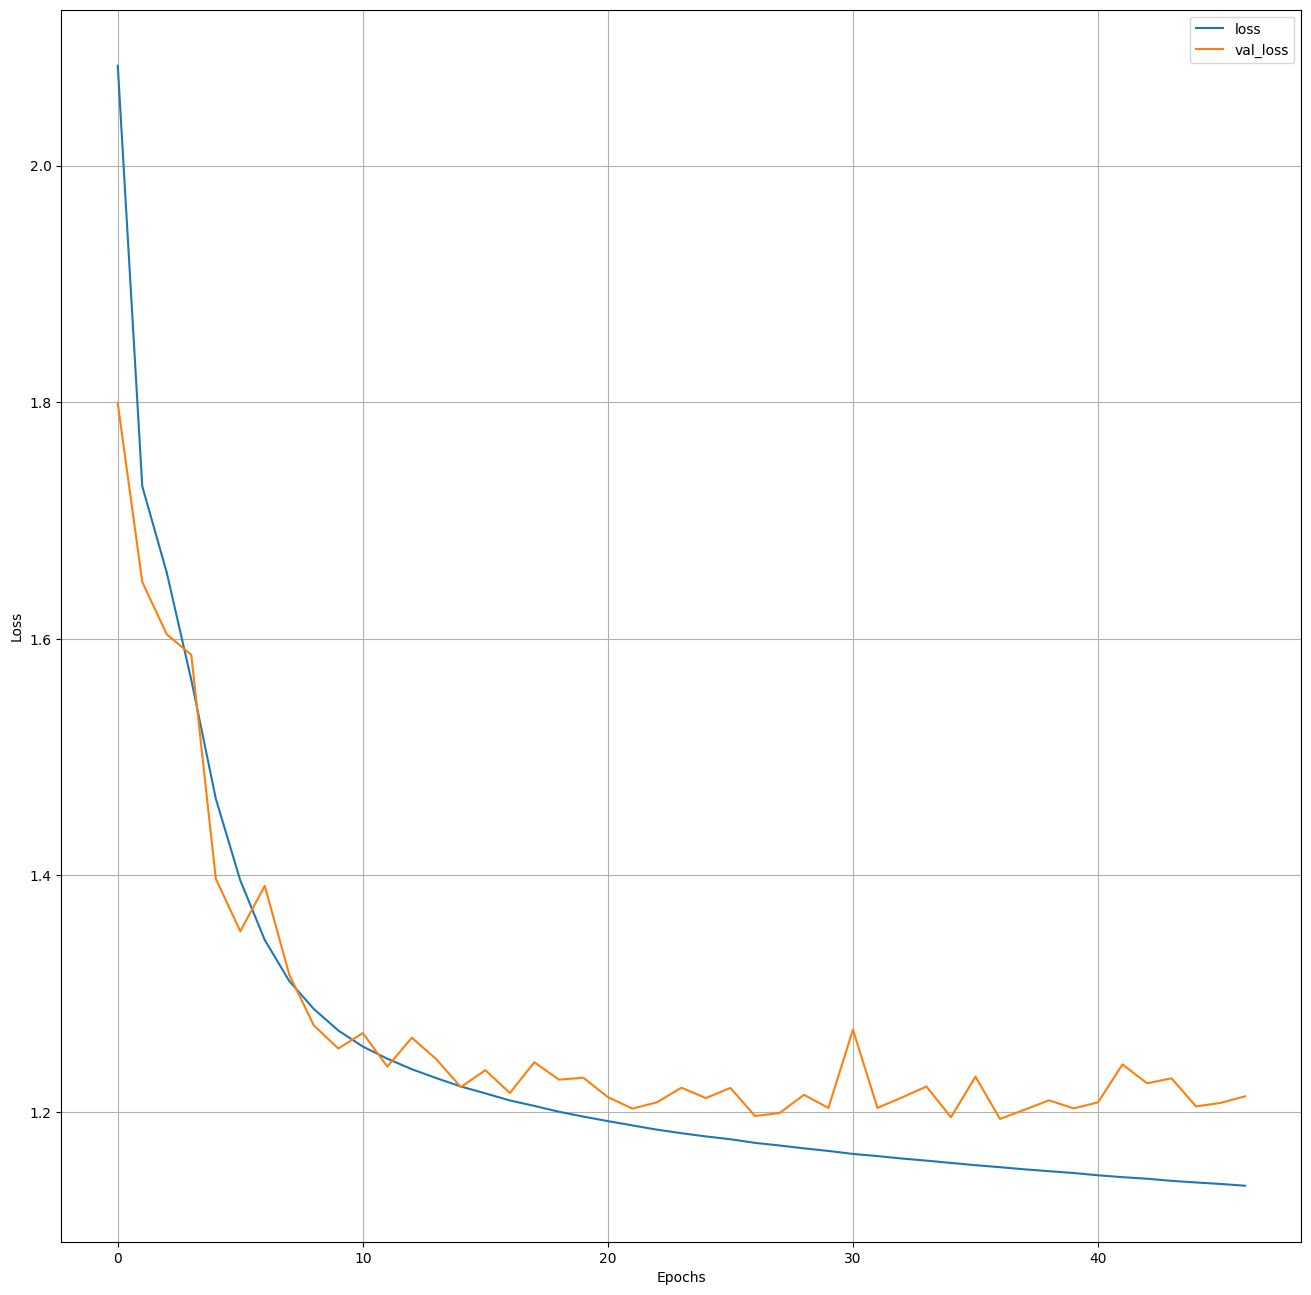

In [7]:
callback = keras.callbacks.EarlyStopping(monitor='val_loss',
                                         restore_best_weights=True,
                                         patience=10)

history = model.fit(X_train,Y_train,epochs=100,validation_data=(X_test, Y_test),batch_size=1024,callbacks=[callback])

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], linewidth=2.5, label='accuracy')
plt.plot(history.history['val_accuracy'], linewidth=2.5, label='val_accuracy')
plt.legend(fontsize=12, frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.savefig('images/training_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], linewidth=2.5, label='loss')
plt.plot(history.history['val_loss'], linewidth=2.5, label='val_loss')
plt.legend(fontsize=12, frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.savefig('images/training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
test_loss, test_acc = model.evaluate(X_test, Y_test)

print("Test accuracy", test_acc)
print("Test loss", test_loss)


15975/15975 ━━━━━━━━━━━━━━━━━━━━ 139s 9ms/step - accuracy: 0.6004 - loss: 1.1973
Test accuracy 0.6012117266654968
Test loss 1.1940562725067139


615/615 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
SNR:  -20 accuracy 0.04334349593495935
614/614 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
SNR:  -18 accuracy 0.0463302752293578
618/618 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
SNR:  -16 accuracy 0.04974696356275304
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
SNR:  -14 accuracy 0.05818107583954272
617/617 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
SNR:  -12 accuracy 0.08337982451691434
615/615 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
SNR:  -10 accuracy 0.1315186975324345
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
SNR:  -8 accuracy 0.1850729687421098
613/613 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
SNR:  -6 accuracy 0.26047674952784444
615/615 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
SNR:  -4 accuracy 0.3364163024697632
611/611 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
SNR:  -2 accuracy 0.41535705144612234
610/610 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
SNR:  0 accuracy 0.5281440812766176
611/611 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
SNR:  2 accuracy 0.6248145305704784
619/619 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
SNR:  4 accur

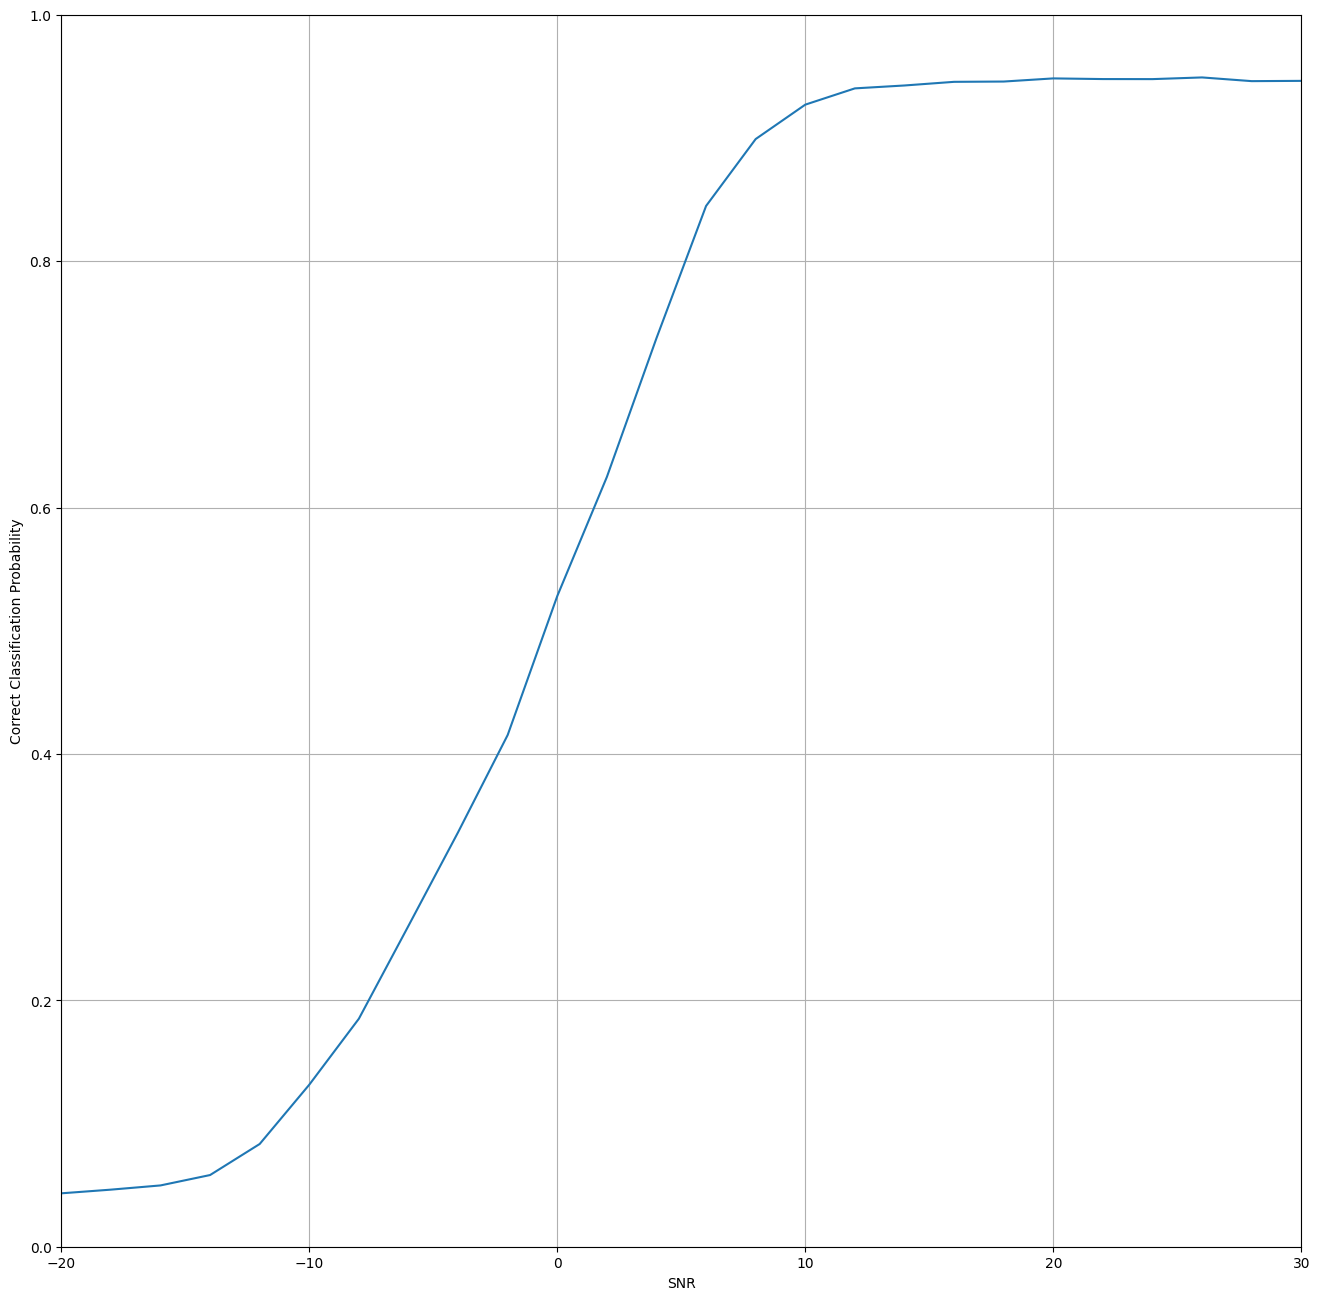

In [9]:
snrlist = np.unique(Z_test)
acc_arr = []

# interate over SNRs
for snr in snrlist:
    i_SNR = np.where(Z_test==snr)
    X_SNR = X_test[i_SNR[0],:,:]
    Y_SNR = Y_test[i_SNR[0],:]
    X_SNR_len = np.shape(X_SNR)[0]

    # model prediction
    pred = model.predict(X_SNR)

    #Pediction values are onehote, corresponding to indices representing different modulation types
    pred_ind = np.argmax(pred, axis=1)
    expected_ind = np.argmax(Y_SNR, axis=1)
    matches  = sum(np.equal(pred_ind, expected_ind))
    acc      = matches/X_SNR_len
    acc_arr.append(acc)
    print("SNR: ", snr, "accuracy", acc)

plt.figure(figsize=(10, 10))
plt.plot(snrlist, acc_arr, linewidth=2.5, color='#2E86AB')
plt.ylabel('Correct Classification Probability', fontsize=14, fontweight='bold')
plt.xlabel('SNR', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xlim([-20, 30]) 
plt.ylim([0, 1])
plt.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.savefig('images/SNR_Accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
def plot_confusion_matrix(cm, title='Confusion matrix >= 0dB SNR', cmap=plt.cm.Blues, labels=[]):
    plt.figure(figsize = (15,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.colorbar()
    label_len = np.shape(labels)[0]
    tick_marks = np.arange(label_len)
    plt.xticks(tick_marks, labels, rotation=45, fontsize=11)
    plt.yticks(tick_marks, labels, fontsize=11)
    plt.tight_layout()    
    plt.ylabel('True label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')
    plt.savefig('images/confusion_matrix.png', dpi=300, bbox_inches='tight')

### Plot confusion matrix for SNR>=0

308/308 ━━━━━━━━━━━━━━━━━━━━ 53s 170ms/step


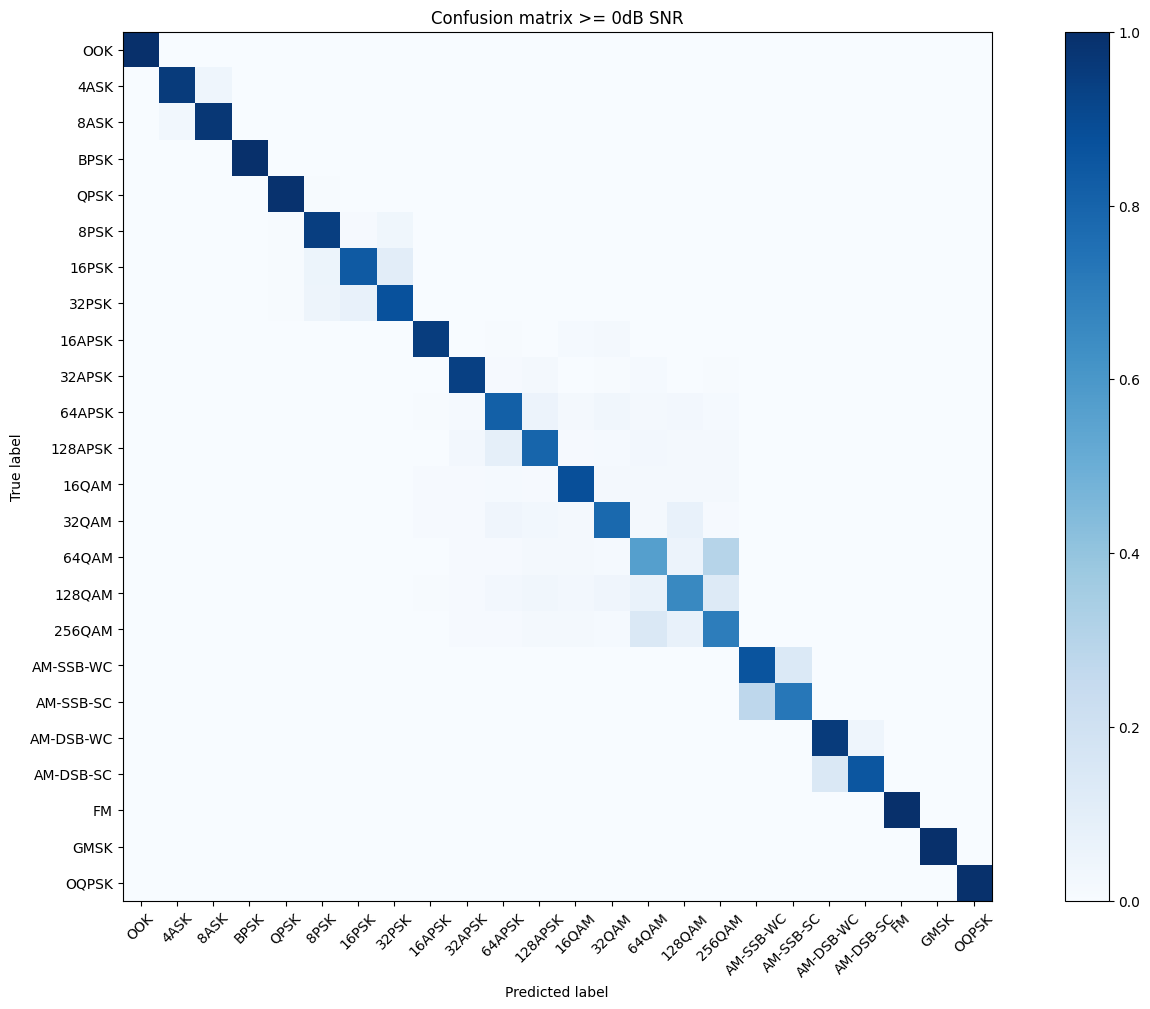

In [11]:
X_test_SNR = X_test[(Z_test>=0)[:,0],:,:]
Y_test_SNR = Y_test[(Z_test>=0)[:,0],:]

test_Y_hat = model.predict(X_test_SNR, batch_size=1024)
conf = np.zeros([24,24])
confnorm = np.zeros([24,24])
for i in range(0,X_test_SNR.shape[0]):
    j = list(Y_test_SNR[i,:]).index(1)
    k = int(np.argmax(test_Y_hat[i,:]))
    conf[j,k] = conf[j,k] + 1
for i in range(0,24):
    confnorm[i,:] = conf[i,:] / np.sum(conf[i,:])

plot_confusion_matrix(confnorm, labels=modulation_classes)

In [ ]:
# Get the model weights from each layer:
w1 = model.get_layer(index=1).get_weights()
w2 = model.get_layer(index=3).get_weights()
w3 = model.get_layer(index=5).get_weights()
w4 = model.get_layer(index=7).get_weights()
w5 = model.get_layer(index=9).get_weights()
w6 = model.get_layer(index=11).get_weights()
w7 = model.get_layer(index=13).get_weights()
w8 = model.get_layer(index=16).get_weights()
w9 = model.get_layer(index=17).get_weights()
w10 = model.get_layer(index=18).get_weights()

# Dump dimensions of weights and bias:
print("conv1 weights shape: ",w1[0].shape, "\t\t# bias: ",len(w1[1]), "\t# params: ",np.prod(w1[0].shape)+len(w1[1]))
print("conv2 weights shape: ",w2[0].shape, "\t\t# bias: ",len(w2[1]), "\t# params: ",np.prod(w2[0].shape)+len(w2[1]))
print("conv3 weights shape: ",w3[0].shape, "\t\t# bias: ",len(w3[1]), "\t# params: ",np.prod(w3[0].shape)+len(w3[1]))
print("conv4 weights shape: ",w4[0].shape, "\t\t# bias: ",len(w4[1]), "\t# params: ",np.prod(w4[0].shape)+len(w4[1]))
print("conv5 weights shape: ",w5[0].shape, "\t\t# bias: ",len(w5[1]), "\t# params: ",np.prod(w5[0].shape)+len(w5[1]))
print("conv6 weights shape: ",w6[0].shape, "\t\t# bias: ",len(w6[1]), "\t# params: ",np.prod(w6[0].shape)+len(w6[1]))
print("conv7 weights shape: ",w7[0].shape, "\t\t# bias: ",len(w7[1]), "\t# params: ",np.prod(w7[0].shape)+len(w7[1]))
print("dense1 weights shape: ",w8[0].shape, "\t\t# bias: ",len(w8[1]), "\t# params: ",np.prod(w8[0].shape)+len(w8[1]))
print("dense2 weights shape: ",w9[0].shape, "\t\t# bias: ",len(w9[1]), "\t# params: ",np.prod(w9[0].shape)+len(w9[1]))
print("dense3 weights shape: ",w10[0].shape, "\t\t# bias: ",len(w10[1]), "\t# params: ",np.prod(w10[0].shape)+len(w10[1]))

np.savetxt('aie/conv1d_w1/w1_weights_trained.txt',np.reshape(w1[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_w1/w1_bias_trained.txt',np.reshape(w1[1].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w3_weights_trained.txt',np.reshape(w2[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w3_bias_trained.txt',np.reshape(w2[1].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w5_weights_trained.txt',np.reshape(w3[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w5_bias_trained.txt',np.reshape(w3[1].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w7_weights_trained.txt',np.reshape(w4[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w7_bias_trained.txt',np.reshape(w4[1].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w9_weights_trained.txt',np.reshape(w5[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w9_bias_trained.txt',np.reshape(w5[1].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w11_weights_trained.txt',np.reshape(w6[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w11_bias_trained.txt',np.reshape(w6[1].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w13_weights_trained.txt',np.reshape(w7[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/conv1d_template/w13_bias_trained.txt',np.reshape(w7[1].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/dense_w16/w16_weights_trained.txt',np.reshape(w8[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/dense_w16/w16_bias_trained.txt',np.reshape(w8[1].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/dense_w17/w17_weights_trained.txt',np.reshape(w9[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/dense_w17/w17_bias_trained.txt',np.reshape(w9[1].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/dense_w18/w18_weights_trained.txt',np.reshape(w10[0].astype("bfloat16"),(-1,1)),fmt="%.12f")
np.savetxt('aie/dense_w18/w18_bias_trained.txt',np.reshape(w10[1].astype("bfloat16"),(-1,1)),fmt="%.12f")


conv1 weights shape:  (7, 2, 64) 		# bias:  64 	# params:  960
conv2 weights shape:  (7, 64, 64) 		# bias:  64 	# params:  28736
conv3 weights shape:  (7, 64, 64) 		# bias:  64 	# params:  28736
conv4 weights shape:  (7, 64, 64) 		# bias:  64 	# params:  28736
conv5 weights shape:  (7, 64, 64) 		# bias:  64 	# params:  28736
conv6 weights shape:  (7, 64, 64) 		# bias:  64 	# params:  28736
conv7 weights shape:  (7, 64, 64) 		# bias:  64 	# params:  28736
dense1 weights shape:  (512, 128) 		# bias:  128 	# params:  65664
dense2 weights shape:  (128, 128) 		# bias:  128 	# params:  16512
dense3 weights shape:  (128, 24) 		# bias:  24 	# params:  3096
